In [4]:
import pandas as pd

df = pd.read_csv('../../course_assignments/homework8/state_data.csv')
print(df.shape) # 54 rows and 4 columns
print(df.head())
print(df.tail())
# postal code abbreviations, latitude, longitude, and full name respectively are the columns represented.
# First state is alaska while the last is Wyoming. There are 52 entries.
# They probably added US territories.
median_lat = df['latitude'].median()
median_long = df['longitude'].median()
df['abs_dist_to_med_lat'] = (df['latitude'] - median_lat).abs()
df['abs_dist_to_med_long'] = (df['longitude'] - median_long).abs()
print(df.shape) # 54 rows and 6 columns
closest_lat = df.iloc[df["abs_dist_to_med_lat"].argmin()]
farthest_lat = df.iloc[df["abs_dist_to_med_lat"].argmax()]
closest_long = df.iloc[df["abs_dist_to_med_long"].argmin()]
farthest_long = df.iloc[df["abs_dist_to_med_long"].argmax()]
print(f"State closest to median latitude is {closest_lat['name']} by {closest_lat['abs_dist_to_med_lat']:.2f}")
print(f"State farthest from median latitude is {farthest_lat['name']} by {farthest_lat['abs_dist_to_med_lat']:.2f}")
print(f"State closest to median longitude is {closest_long['name']} by {closest_long['abs_dist_to_med_long']:.2f}")
print(f"State farthest from median longitude is {farthest_long['name']} by {farthest_long['abs_dist_to_med_long']:.2f}")
# using idxmin and idxmax to find the name of the row with the closest and farthest value. can use with loc instead of using iloc and argmin/argmax
# found it in the dataframe section in the api refrence.
closest_lat = df.loc[df["abs_dist_to_med_lat"].idxmin()]
print(f"State closest to median latitude is {closest_lat['name']} by {closest_lat['abs_dist_to_med_lat']:.2f}")

(52, 4)
  state   latitude   longitude        name
0    AK  63.588753 -154.493062      Alaska
1    AL  32.318231  -86.902298     Alabama
2    AR  35.201050  -91.831833    Arkansas
3    AZ  34.048928 -111.093731     Arizona
4    CA  36.778261 -119.417932  California
   state   latitude   longitude           name
47    VT  44.558803  -72.577841        Vermont
48    WA  47.751074 -120.740139     Washington
49    WI  43.784440  -88.787868      Wisconsin
50    WV  38.597626  -80.454903  West Virginia
51    WY  43.075968 -107.290284        Wyoming
(52, 6)
State closest to median latitude is Colorado by 0.11
State farthest from median latitude is Alaska by 24.15
State closest to median longitude is Illinois by 0.31
State farthest from median longitude is Hawaii by 66.57
State closest to median latitude is Colorado by 0.11


(398, 9)
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  
      mpg  cylinders  displacement  horsepower  weight  acceleration  \
393  27.0          4         140.0        86.0    2790          15.6   
394  44.0          4          97.0        52.0    2130          24.6   
395  32.0          4         135.0        84.0    2295

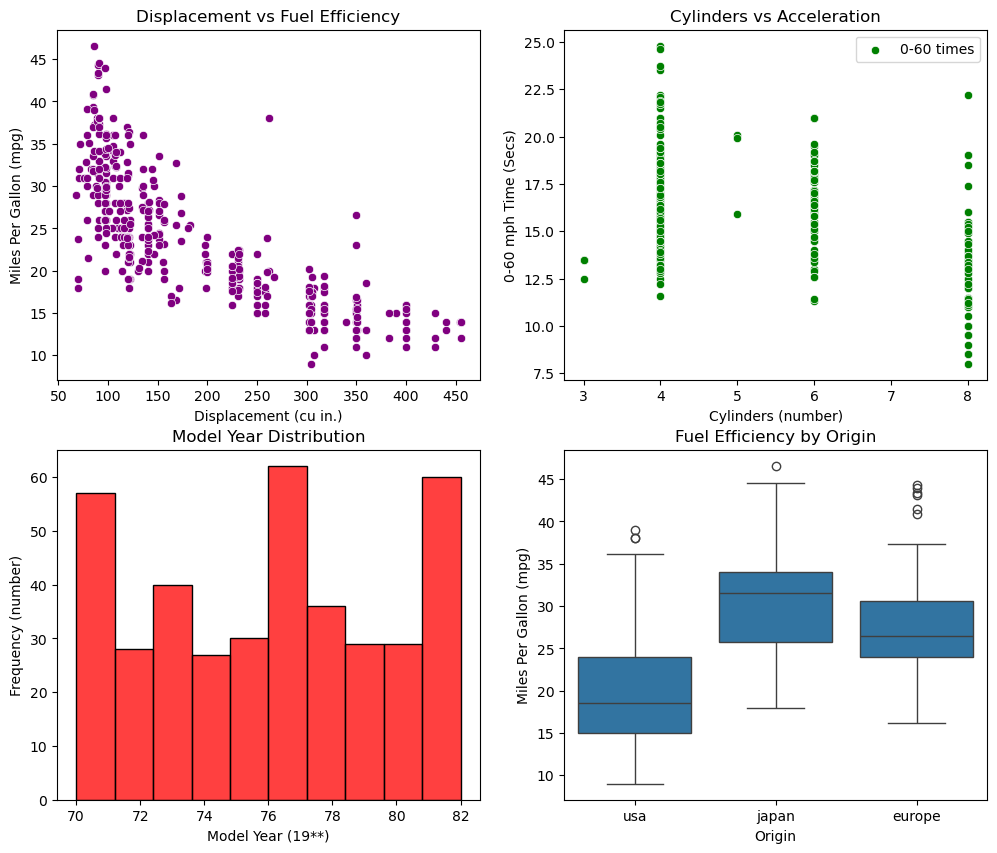

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
data = sns.load_dataset('mpg')
data.dropna(axis=1)
print(data.shape) # shape is (398, 9)
# there are 398 rows and 9 columns
print(data.head())
print(data.tail())
# mpg = miles per gallon, cylinders = amount of cyclinders the engine is made of, displacement = total volume of the cyoinders in the engine \ 
# horsepower = how much power it produces, weight = how heavy, acceleration = time to get to 60mph, mpdel year = year made, origin, = where made, name
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.scatterplot(data = data, x='displacement', y='mpg', ax=axes[0, 0], color = 'purple')
axes[0, 0].set_title('Displacement vs Fuel Efficiency')
axes[0, 0].set_xlabel('Displacement (cu in.)')
axes[0, 0].set_ylabel('Miles Per Gallon (mpg)')
sns.scatterplot(data = data, x='cylinders', y='acceleration', ax=axes[0, 1], label = "0-60 times", color = 'green')
axes[0, 1].set_title('Cylinders vs Acceleration')
axes[0, 1].set_xlabel('Cylinders (number)')
axes[0, 1].set_ylabel('0-60 mph Time (Secs)')
axes[0, 1].legend()
sns.histplot(data=data, x='model_year', ax=axes[1, 0], color = 'red')
axes[1, 0].set_title('Model Year Distribution')
axes[1, 0].set_xlabel('Model Year (19**)')
axes[1, 0].set_ylabel('Frequency (number)')
sns.boxplot(data=data, x='origin', y='mpg', ax=axes[1, 1])
axes[1, 1].set_title('Fuel Efficiency by Origin')
axes[1, 1].set_xlabel('Origin')
axes[1, 1].set_ylabel('Miles Per Gallon (mpg)')
plt.show()
# top left looks at displacement to mpg. did this to look at how much displacement affects furl efficiency. found that less displacement leads to better mpg.
# top right is cylinders v acceleration to see if more cylinders means more acceleartion. found that more cylinders generally means better acceleration.
# bottom left is number of cars in each model year to see which years had the most cars. found that it was generally even except two spikes.
# bottom right is fuel efficiency by origin to see which areas make the most fuel efficient vehicles. Japan had the more fuel efficient vehicles.